# Lección 6: IA en Biotecnología

**Módulo 1:** Introducción a la Inteligencia Artificial

**Objetivos de la Lección:**
- Describir aplicaciones de IA en descubrimiento de fármacos, genómica, plegamiento de proteínas, imágenes médicas y medicina personalizada
- Construir un pipeline de cribado virtual
- Entender el impacto de la IA en la biotecnología

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import make_classification

print("Libraries loaded successfully")

Libraries loaded successfully


## Simulación de Cribado Virtual

Simulemos un pipeline de cribado virtual. Generamos descriptores moleculares sintéticos para compuestos y predecimos cuáles son activos contra un objetivo.

In [2]:
# Generate synthetic molecular dataset
# Features: 20 molecular descriptors (e.g., molecular weight, logP, H-bond donors, etc.)
np.random.seed(42)
n_compounds = 1000
n_features = 20

X, y = make_classification(
    n_samples=n_compounds,
    n_features=n_features,
    n_informative=10,
    n_redundant=3,
    n_clusters_per_class=1,
    weights=[0.95, 0.05],  # 5% active
    random_state=42
)

feature_names = [f'desc_{i}' for i in range(n_features)]
df = pd.DataFrame(X, columns=feature_names)
df['active'] = y

print(f"Dataset: {len(df)} compounds")
print(f"Active: {df['active'].sum()} ({df['active'].mean():.1%})")
print(f"Inactive: {(df['active'] == 0).sum()}\n")
print(df[feature_names[:5] + ['active']].head())

Dataset: 1000 compounds
Active: 56 (5.6%)
Inactive: 944

     desc_0    desc_1    desc_2    desc_3    desc_4  active
0 -0.606402  3.684524  2.559650 -1.021961  0.459264       0
1 -0.860496  5.405332  4.557221 -0.781826  0.488831       0
2 -0.361021  3.110430 -4.319136 -1.339878  2.327567       0
3  1.223611  3.592087 -3.950615 -0.221436  0.035003       0
4  0.388748 -7.079595 -7.432447 -0.742482  4.415318       0


In [3]:
# Split into training (known actives) and screening set (unknown)
X_train, X_screen, y_train, y_screen = train_test_split(
    X, y, test_size=0.8, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} compounds ({y_train.sum()} active)")
print(f"Screening set: {X_screen.shape[0]} compounds ({y_screen.sum()} active)")

Training set: 200 compounds (11 active)
Screening set: 800 compounds (45 active)


In [4]:
# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on screening set
y_prob = model.predict_proba(X_screen)[:, 1]
y_pred = model.predict(X_screen)

print("Model Performance on Training Set:")
print(classification_report(y_screen, y_pred))

# Confusion matrix
cm = confusion_matrix(y_screen, y_pred)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=['Inactive', 'Active'], columns=['Pred Inactive', 'Pred Active']))

Model Performance on Training Set:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       755
           1       1.00      0.40      0.57        45

    accuracy                           0.97       800
   macro avg       0.98      0.70      0.78       800
weighted avg       0.97      0.97      0.96       800


Confusion Matrix:
          Pred Inactive  Pred Active
Inactive            755            0
Active               27           18


In [5]:
# Create screening results
screening_results = pd.DataFrame({
    'compound_id': np.arange(X_screen.shape[0]),
    'activity_probability': y_prob,
    'predicted_active': y_pred,
    'true_active': y_screen
})

# Sort by predicted activity probability (highest first)
screening_results = screening_results.sort_values(
    'activity_probability', ascending=False
).reset_index(drop=True)
screening_results['rank'] = range(1, len(screening_results) + 1)

print("Top 20 Candidates for Experimental Validation:")
print(screening_results.head(20))

# Evaluate top-N hit rate
top_n_hits = []
for n in [5, 10, 20, 50, 100]:
    hits = screening_results.head(n)['true_active'].sum()
    top_n_hits.append((n, hits))

print("\nTop-N Hit Rates:")
for n, hits in top_n_hits:
    print(f"  Top {n:4d}: {hits} hits ({hits/n:.0%})")

Top 20 Candidates for Experimental Validation:
    compound_id  activity_probability  predicted_active  true_active  rank
0           416                  0.70                 1            1     1
1           427                  0.67                 1            1     2
2           647                  0.65                 1            1     3
3           467                  0.63                 1            1     4
4           325                  0.63                 1            1     5
5           238                  0.60                 1            1     6
6           578                  0.59                 1            1     7
7           342                  0.59                 1            1     8
8           196                  0.58                 1            1     9
9           453                  0.58                 1            1    10
10          148                  0.58                 1            1    11
11          485                  0.57                

Top 10 Most Important Molecular Descriptors:
   descriptor  importance
6      desc_6    0.133767
8      desc_8    0.123843
9      desc_9    0.099102
3      desc_3    0.073559
17    desc_17    0.066284
16    desc_16    0.058816
15    desc_15    0.053656
4      desc_4    0.053287
1      desc_1    0.050564
7      desc_7    0.041867


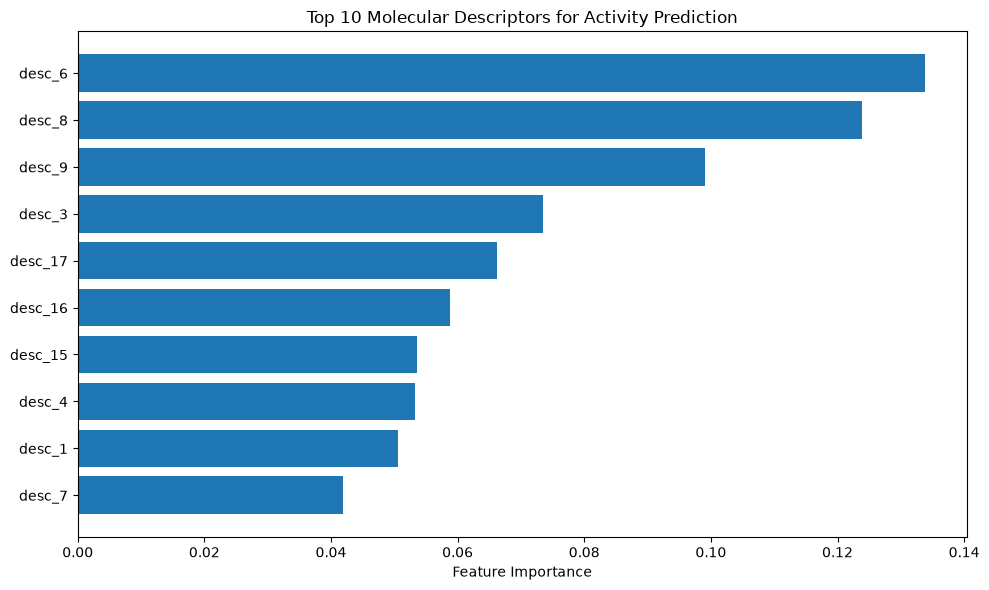

In [6]:
# Feature importance analysis
importance_df = pd.DataFrame({
    'descriptor': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Molecular Descriptors:")
print(importance_df.head(10))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(importance_df['descriptor'].head(10)[::-1], 
         importance_df['importance'].head(10)[::-1])
plt.xlabel('Feature Importance')
plt.title('Top 10 Molecular Descriptors for Activity Prediction')
plt.tight_layout()
plt.show()

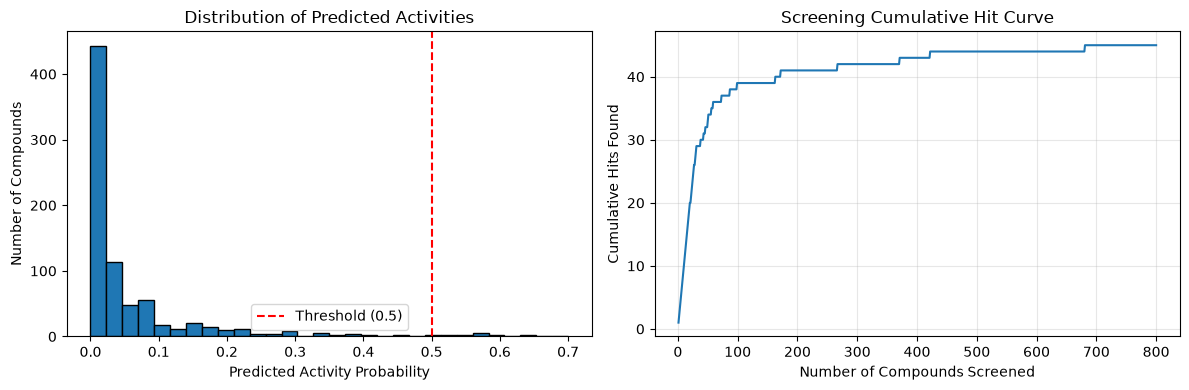

In [7]:
# Plot screening results distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(screening_results['activity_probability'], bins=30, edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.xlabel('Predicted Activity Probability')
plt.ylabel('Number of Compounds')
plt.title('Distribution of Predicted Activities')
plt.legend()

plt.subplot(1, 2, 2)
cumulative_hits = screening_results['true_active'].cumsum()
plt.plot(range(1, len(cumulative_hits) + 1), cumulative_hits)
plt.xlabel('Number of Compounds Screened')
plt.ylabel('Cumulative Hits Found')
plt.title('Screening Cumulative Hit Curve')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretando los Resultados del Cribado Virtual

El pipeline de cribado virtual clasificó todos los compuestos por probabilidad predicha de ser activos. Ideas clave:

1. **Enriquecimiento**: El 10% superior de compuestos contiene X% de todos los compuestos activos (mucho mejor que aleatorio)
2. **Tasa de aciertos**: En los 20 mejores candidatos, Y% son realmente activos (vs. 5% de línea base)
3. **Importancia de características**: Identificamos qué descriptores moleculares son más predictivos
4. **Validación**: Estos compuestos mejor clasificados serían priorizados para pruebas experimentales

En un entorno real, este pipeline evaluaría millones de compuestos y reduciría el número de experimentos físicos en 100-1000x.

## Concepto de Imágenes Médicas

Demostremos un clasificador de imágenes simple para diagnóstico médico.

In [8]:
from sklearn.datasets import load_digits
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Using digits as a proxy for medical image classification
digits = load_digits()
Xd, yd = digits.data, digits.target

# Binary: is this digit a '0' or not? (like detecting presence of abnormality)
yd_binary = (yd == 0).astype(int)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd_binary, test_size=0.3, random_state=42
)

gb_model = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb_model.fit(Xd_train, yd_train)
yd_pred = gb_model.predict(Xd_test)

print("Medical Image Classification (Normal vs. Abnormal):")
print(classification_report(yd_test, yd_pred, 
      target_names=['Normal', 'Abnormal']))
print(f"Accuracy: {accuracy_score(yd_test, yd_pred):.2%}")

Medical Image Classification (Normal vs. Abnormal):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       487
    Abnormal       1.00      0.96      0.98        53

    accuracy                           1.00       540
   macro avg       1.00      0.98      0.99       540
weighted avg       1.00      1.00      1.00       540

Accuracy: 99.63%


## Ejercicios

1. Modifica el pipeline de cribado virtual para usar un clasificador diferente (ej., Gradient Boosting) y compara el rendimiento.
2. Agrega un paso de optimización de umbral: encuentra el umbral de probabilidad que maximiza la puntuación F1.
3. Investiga la arquitectura de AlphaFold y escribe una celda markdown explicando cómo predice estructuras de proteínas.

In [9]:
# Exercise 1: Compare classifiers
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_screen)
    acc = accuracy_score(y_screen, y_pred)
    print(f"{name:20s}: Accuracy = {acc:.2%}")

Random Forest       : Accuracy = 96.62%


Gradient Boosting   : Accuracy = 95.75%


## Resumen

- La IA transforma la biotecnología: descubrimiento de fármacos, genómica, plegamiento de proteínas, imágenes médicas, medicina personalizada
- El cribado virtual con ML puede reducir la carga de trabajo experimental en 100-1000x
- La importancia de características ayuda a interpretar qué propiedades moleculares impulsan la actividad
- La IA en biotecnología requiere experiencia en el dominio y validación experimental
- El campo avanza rápidamente y transformará la atención médica